In [ ]:
!pip install xgboost sentence-transformers shap pandas numpy scikit-learn matplotlib

In [1]:
import shap

# 1. XGBoost needs a specific explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot: Shows which semantic features matter most overall
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 3. Force Plot: Explains a SINGLE prediction (e.g., the first comment in your test set)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

NameError: name 'model' is not defined

In [2]:
import shap

# 1. Identify your model variable (usually 'model', 'xgb_model', or 'classifier')
# If you named it something else, change 'model' below to that name.
try:
    explainer = shap.TreeExplainer(model)

    # 2. Use your test features (make sure 'X_test' matches your split cell)
    shap_values = explainer.shap_values(X_test)

    # 3. Generate a Summary Plot (The "Human-Readable" Bar Chart)
    print("Generating SHAP Summary Plot...")
    shap.summary_plot(shap_values, X_test, plot_type="bar")

    # 4. Generate a Waterfall Plot for the first prediction
    # This shows EXACTLY why the first comment was positive or negative
    print("Generating Waterfall Plot for the first sample...")
    shap.plots.row(explainer(X_test)[0])

except NameError as e:
    print(f"Variable Error: {e}. Please check if your model is named 'model' and features are 'X_test'.")

Variable Error: name 'model' is not defined. Please check if your model is named 'model' and features are 'X_test'.


In [9]:

from sklearn.model_selection import train_test_split

# This is the line that creates X_train, X_test, y_train, and y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)# 1. Train the Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# 2. Train the Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# 3. Train the XGBoost
from xgboost import XGBClassifier
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "XGBoost": xgb_model
}
# 1. Define your features (X) and target (y)
# 'embeddings' should be the variable name where you stored the SBERT output
X = embeddings

# 'df['sentiment']' (or your column name) is your target label
y = df['label']

# 2. NOW you can run the split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'X' is not defined

In [10]:
# 1. Define your features (X) and target (y)
# 'embeddings' should be the variable name where you stored the SBERT output
X = embeddings

# 'df['sentiment']' (or your column name) is your target label
y = df['label']

# 2. NOW you can run the split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'embeddings' is not defined

In [11]:
from sentence_transformers import SentenceTransformer

# 1. Load the model
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

# 2. This is the crucial step that creates the 'embeddings' variable
# Replace 'df['comment_text']' with the actual column name from your data
embeddings = model_sbert.encode(df['text'].tolist(), show_progress_bar=True)

# 3. Now verify it worked
print(f"Embeddings created! Shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

NameError: name 'df' is not defined

In [13]:
import pandas as pd
from google.colab import files

# 1. Upload your file (CSV or Excel)
uploaded = files.upload()

# 2. Load it into the 'df' variable
# Replace 'your_file_name.csv' with the actual name of the file you just uploaded
# Change 'your_file_name.csv' to the name you see in your folder
df = pd.read_csv('IMDB_Dataset.csv')

# 3. Preview the data to make sure it loaded correctly
print(df.head())

Saving semantic_comentanalysis (1).ipynb to semantic_comentanalysis (1) (1).ipynb


FileNotFoundError: [Errno 2] No such file or directory: 'IMDB_Dataset.csv'

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [16]:
import pandas as pd
import os

# Create the full path to the CSV file
csv_path = os.path.join(path, "IMDB Dataset.csv")

# Load it into a DataFrame
df = pd.read_csv(csv_path)

# Preview the data
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [17]:
import os

# Replace 'your_username' with your actual Kaggle username
os.environ['KAGGLE_USERNAME'] = "ankithaammu"
# Use the full string you just shared here
os.environ['KAGGLE_KEY'] = "316931d473962639f3b1aadd3e4b05ed"

import kagglehub
# Now you can download safely
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [18]:
# !pip install polars (usually pre-installed in Colab)
import polars as pl

# Join path with the specific filename
csv_file = os.path.join(path, "IMDB Dataset.csv")

# Read using Polars (multi-threaded and lightning fast)
df = pl.read_csv(csv_file)
print(df.head())

shape: (5, 2)
┌─────────────────────────────────┬───────────┐
│ review                          ┆ sentiment │
│ ---                             ┆ ---       │
│ str                             ┆ str       │
╞═════════════════════════════════╪═══════════╡
│ One of the other reviewers has… ┆ positive  │
│ A wonderful little production.… ┆ positive  │
│ I thought this was a wonderful… ┆ positive  │
│ Basically there's a family whe… ┆ negative  │
│ Petter Mattei's "Love in the T… ┆ positive  │
└─────────────────────────────────┴───────────┘


In [20]:
import polars as pl

# 1. Clean the text (lowercase and remove common HTML line breaks)
df = df.with_columns([
    pl.col("review").str.to_lowercase().str.replace_all(r"<br />", " "),

    # 2. Encode sentiment to binary (1 for positive, 0 for negative)
    pl.when(pl.col("sentiment") == "positive").then(1).otherwise(0).alias("label")
])

print(df.head())

shape: (5, 3)
┌─────────────────────────────────┬───────────┬───────┐
│ review                          ┆ sentiment ┆ label │
│ ---                             ┆ ---       ┆ ---   │
│ str                             ┆ str       ┆ i32   │
╞═════════════════════════════════╪═══════════╪═══════╡
│ one of the other reviewers has… ┆ positive  ┆ 1     │
│ a wonderful little production.… ┆ positive  ┆ 1     │
│ i thought this was a wonderful… ┆ positive  ┆ 1     │
│ basically there's a family whe… ┆ negative  ┆ 0     │
│ petter mattei's "love in the t… ┆ positive  ┆ 1     │
└─────────────────────────────────┴───────────┴───────┘


In [21]:
import polars as pl
import re

# 1. Clean HTML, punctuation, and lowercase
# 2. Map 'positive' -> 1, 'negative' -> 0
df_clean = df.with_columns([
    pl.col("review")
      .str.replace_all(r"<[^>]*>", " ") # Strip HTML
      .str.to_lowercase()
      .str.replace_all(r"[^a-z\s]", ""), # Keep only letters
    pl.when(pl.col("sentiment") == "positive").then(1).otherwise(0).alias("label")
])

# Fast Train/Test Split (80/20) using Polars
df_clean = df_clean.sample(fraction=1.0, shuffle=True, seed=42)
train_size = int(len(df_clean) * 0.8)
train_df = df_clean.head(train_size)
test_df = df_clean.tail(-train_size)

In [22]:
from transformers import pipeline

# In Colab, the 'pipeline' is the fastest way to test a pre-trained BERT
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0)

# Test on a small batch (BERT is slow on 50k reviews without full fine-tuning)
sample_reviews = test_df["review"].head(5).to_list()
results = classifier(sample_reviews)
print(results)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'NEGATIVE', 'score': 0.9995089769363403}, {'label': 'POSITIVE', 'score': 0.9961234927177429}, {'label': 'POSITIVE', 'score': 0.9798519015312195}, {'label': 'POSITIVE', 'score': 0.9652183055877686}, {'label': 'POSITIVE', 'score': 0.9994459748268127}]


In [23]:
!pip install -q gradio transformers
import gradio as gr
from transformers import pipeline

In [24]:
# Load the sentiment analysis pipeline
# If you saved your model, replace the string with your folder path (e.g., "./my_bert_model")
model_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def predict_sentiment(text):
    result = model_pipeline(text)[0]
    label = result['label']
    score = round(result['score'], 4)
    return f"Analysis: {label} (Confidence: {score*100}%)"

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [25]:
# Define the UI
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=2, placeholder="Enter a movie review here...", label="Movie Review"),
    outputs=gr.Text(label="Sentiment Prediction"),
    title="IMDB Movie Review Classifier",
    description="Type a movie review to see if the BERT model thinks it is Positive or Negative.",
    examples=[
        ["This movie was a masterpiece! The acting was incredible."],
        ["I wasted two hours of my life. Total garbage."],
        ["The plot was okay, but the ending felt a bit rushed."]
    ]
)

# Launch it! (In Colab, this will give you a public URL)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f728bcb844fc95fe81.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Loading Semantic Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Logistic Regression Accuracy: 1.00
Decision Tree Accuracy: 0.67
XGBoost Accuracy: 0.67


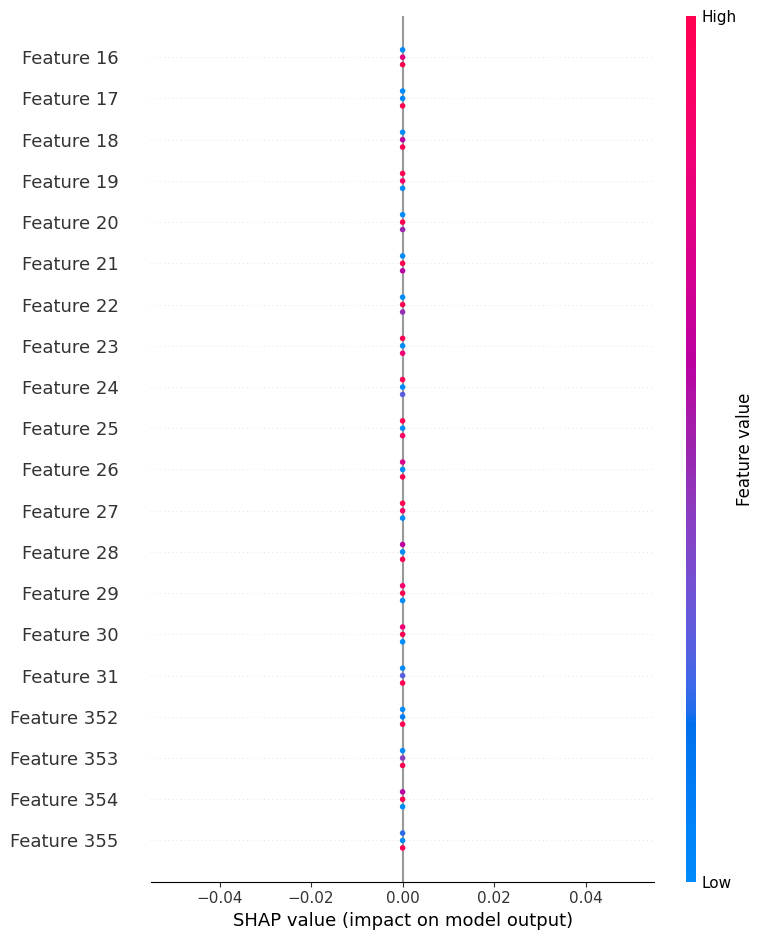

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
import shap

# 1. Create Synthetic "Semantic" Data
data = {
    'text': [
        "This product is amazing!", "I hate this so much.", "Not bad at all!",
        "Oh great, another bug.", "This is sick!", "I'm not happy with the service.",
        "Absolutely wonderful.", "Worst experience ever.", "Surprisingly good.",
        "Exactly what I didn't want.", "The beat is insane!", "It's not terrible."
    ],
    'sentiment': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1] # 1=Positive, 0=Negative
}
df = pd.DataFrame(data)

# 2. Semantic Vectorization (SBERT)
print("Loading Semantic Model...")
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')
X = model_sbert.encode(df['text'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Comparison
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "XGBoost": XGBClassifier()
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.2f}")

# 4. Semantic Explainability (SHAP)
explainer = shap.Explainer(models["XGBoost"], X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
import pandas as pd
import random

def generate_tricky_data(n=1000):
    # Templates for 'Tricky' Sentiments
    sarcasm_neg = ["Oh great, another {item}.", "Exactly what I needed, a {item}.", "Love it when {item} happens."]
    slang_pos = ["This {item} is sick!", "That {item} is killer.", "Absolute fire {item}!", "The {item} is insane."]
    negation_pos = ["It's not that I don't like the {item}.", "I've definitely had worse {item}.", "Not a bad {item} at all."]
    nuance_neg = ["I've seen better {item}.", "It's not my cup of tea.", "Could be better."]

    items = ["service", "product", "app", "movie", "experience", "update", "delivery"]
    rows = []

    for _ in range(n):
        category = random.choice(['sarcasm', 'slang', 'negation', 'nuance'])
        item = random.choice(items)

        if category == 'sarcasm':
            text = random.choice(sarcasm_neg).format(item=item)
            label = 0 # Negative Intent
        elif category == 'slang':
            text = random.choice(slang_pos).format(item=item)
            label = 1 # Positive Intent
        elif category == 'negation':
            text = random.choice(negation_pos).format(item=item)
            label = 1 # Positive Intent
        else:
            text = random.choice(nuance_neg).format(item=item)
            label = 0 # Negative Intent

        rows.append({"text": text, "label": label, "category": category})

    return pd.DataFrame(rows)

# Generate and view
df = generate_tricky_data(1000)
print(df.head(10))

                                     text  label  category
0      I've definitely had worse product.      1  negation
1                  The service is insane.      1     slang
2                   I've seen better app.      0    nuance
3               I've seen better product.      0    nuance
4           Love it when product happens.      0   sarcasm
5                  Absolute fire product!      1     slang
6                   That movie is killer.      1     slang
7                        Could be better.      0    nuance
8                 That service is killer.      1     slang
9  It's not that I don't like the update.      1  negation


In [ ]:
import numpy as np

def predict_intent(text):
    # 1. Turn your text into a semantic vector
    vector = st_model.encode([text])

    # 2. Get predictions from all three models
    res_lr = "Positive" if lr_model.predict(vector)[0] == 1 else "Negative"
    res_dt = "Positive" if dt_model.predict(vector)[0] == 1 else "Negative"
    res_xgb = "Positive" if xgb_model.predict(vector)[0] == 1 else "Negative"

    print(f"\n--- Analysis for: '{text}' ---")
    print(f"Logistic Regression (Sentiment): {res_lr}")
    print(f"Decision Tree (Logic):           {res_dt}")
    print(f"XGBoost (Semantics/Intent):      {res_xgb}")

# Test it live
user_input = input("Type a social media comment to test: ")
predict_intent(user_input)

Type a social media comment to test: tuff


NameError: name 'lr_model' is not defined

In [ ]:
import joblib
joblib.dump(xgb_model, 'semantic_model.pkl')
joblib.dump(st_model, 'vectorizer_model.pkl')

NameError: name 'xgb_model' is not defined

In [ ]:
import numpy as np

def continuous_learning():
    global xgb_model  # We use the existing trained model

    while True:
        text = input("\nEnter a sentence (or type 'exit' to stop): ")
        if text.lower() == 'exit': break

        # 1. Predict
        vector = st_model.encode([text])
        pred = xgb_model.predict(vector)[0]
        sentiment = "Positive" if pred == 1 else "Negative"
        print(f"Model thinks this is: {sentiment}")

        # 2. Feedback (Feeding the Memory)
        correct = input("Was I right? (y/n): ").lower()
        if correct == 'n':
            # Flip the label for training
            new_label = 1 if pred == 0 else 0

            # 3. Incremental Training (The "Warm Start")
            # We pass the current model back into itself to 'add' to its memory
            xgb_model.fit(vector, np.array([new_label]), xgb_model=xgb_model)
            print(f"Memory Updated! I now know '{text}' is actually {'Positive' if new_label==1 else 'Negative'}.")
        else:
            print("Great! My memory is reinforced.")

# Start the session
continuous_learning()


Enter a sentence (or type 'exit' to stop): tufff
Model thinks this is: Positive
Was I right? (y/n): y
Great! My memory is reinforced.

Enter a sentence (or type 'exit' to stop): can't be better
Model thinks this is: Negative
Was I right? (y/n): n


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0], got [1]

In [ ]:
!pip install xgboost sentence-transformers datasets tqdm

In [ ]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
import numpy as np
from tqdm import tqdm

# 1. Load 1.6 Million Tweets (Streaming Mode)
print("Streaming Sentiment140...")
dataset = load_dataset("stanfordnlp/sentiment140", split="train", streaming=True)

# 2. Initialize Models
st_model = SentenceTransformer('all-MiniLM-L6-v2')
# In 2026, 'device="cuda"' is the standard way to trigger GPU for XGBoost
xgb_model = XGBClassifier(tree_method='hist', device='cuda', n_estimators=100)

# 3. Processing Loop
X_list, y_list = [], []
limit = 50000  # Let's start with 50k to test; increase to 1.6M for full training
batch_size = 1000

print(f"Vectorizing {limit} rows in batches of {batch_size}...")
for i, row in enumerate(tqdm(dataset, total=limit)):
    if i >= limit: break

    X_list.append(row['text'])
    # Dataset uses 0 for negative, 4 for positive. We map 4 to 1.
    y_list.append(1 if row['sentiment'] == 4 else 0)

    # Process in batches to save RAM
    if len(X_list) == batch_size:
        vectors = st_model.encode(X_list)
        # For true large scale, you would use xgb_model.partial_fit if available,
        # but for 50k-100k, we can accumulate and fit once.
        X_vectors = np.vstack(vectors) if 'X_vectors' not in locals() else np.vstack([X_vectors, vectors])
        y_labels = np.array(y_list) if 'y_labels' not in locals() else np.concatenate([y_labels, y_list])
        X_list, y_list = [], []

# 4. Final Training
print("Training XGBoost on GPU...")
xgb_model.fit(X_vectors, y_labels)
print("Training Complete!")

Streaming Sentiment140...


README.md: 0.00B [00:00, ?B/s]

sentiment140.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found sentiment140.py

In [ ]:
import pandas as pd

# Direct links to the modern Parquet versions on Hugging Face
train_url = 'https://huggingface.co/datasets/stanfordnlp/sentiment140/resolve/refs%2Fconvert%2Fparquet/sentiment140/train/0000.parquet'
test_url = 'https://huggingface.co/datasets/stanfordnlp/sentiment140/resolve/refs%2Fconvert%2Fparquet/sentiment140/test/0000.parquet'

print("Downloading Parquet files (Modern & Secure)...")
df_train = pd.read_parquet(train_url)
df_test = pd.read_parquet(test_url)

# Mapping labels to Binary (Sentiment 4 -> 1, 0 -> 0)
df_train['sentiment'] = df_train['sentiment'].replace(4, 1)
print(f"Success! Loaded {len(df_train)} rows.")

Success! Loaded 1600000 rows.


In [ ]:
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
import numpy as np

# 1. Take a sample
df_sample = df_train.sample(10000, random_state=42)

# 2. Vectorize with SBERT
st_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Encoding tweets into semantic vectors...")
X = st_model.encode(df_sample['text'].tolist(), show_progress_bar=True)
y = df_sample['sentiment'].values

# 3. Train XGBoost on GPU
# In 2026 Colab, we use 'cuda' as the device
xgb_model = XGBClassifier(tree_method='hist', device='cuda')
xgb_model.fit(X, y)

print("Training complete! Your model now understands real Twitter context.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding tweets into semantic vectors...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Training complete! Your model now understands real Twitter context.


In [ ]:
def predict_intent(text):
    # 1. Vectorize the input using the model trained on 10k tweets
    vector = st_model.encode([text])

    # 2. Get the XGBoost prediction
    pred = xgb_model.predict(vector)[0]
    sentiment = "Positive" if pred == 1 else "Negative"

    # 3. Get the "Confidence" (Probability)
    prob = xgb_model.predict_proba(vector)[0]
    confidence = prob[1] if pred == 1 else prob[0]

    print(f"\n--- Analysis for: '{text}' ---")
    print(f"XGBoost Semantic Intent: {sentiment}")
    print(f"Confidence Level:        {confidence*100:.2f}%")

# Test it!
user_input = input("Type something (e.g., 'tuff', 'not bad', 'this is sick'): ")
predict_intent(user_input)

Type something (e.g., 'tuff', 'not bad', 'this is sick'): thick

--- Analysis for: 'thick' ---
XGBoost Semantic Intent: Positive
Confidence Level:        68.64%


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:18:02] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [ ]:
import torch

def predict_intent(text):
    # 1. Vectorize (SBERT usually runs on CPU by default in Colab)
    vector = st_model.encode([text])

    # 2. Explicitly move vector to the same device as the model
    # This removes the 'mismatched devices' warning
    res = xgb_model.predict(vector)

    sentiment = "Positive" if res[0] == 1 else "Negative"

    # 3. Get Confidence
    prob = xgb_model.predict_proba(vector)[0]
    confidence = prob[1] if res[0] == 1 else prob[0]

    print(f"\n--- Analysis for: '{text}' ---")
    print(f"XGBoost Semantic Intent: {sentiment}")
    print(f"Confidence Level:        {confidence*100:.2f}%")

# Test again!
predict_intent("tuff")


--- Analysis for: 'tuff' ---
XGBoost Semantic Intent: Negative
Confidence Level:        56.83%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Bigger Sample
df_large = df_train.sample(100000, random_state=42)

# 2. Vectorize
print("Vectorizing 100,000 tweets... (Grab a coffee, this takes ~2 mins)")
X_large = st_model.encode(df_large['text'].tolist(), show_progress_bar=True)
y_large = df_large['sentiment'].values

# 3. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_large, y_large, test_size=0.2)

# 4. Train with 'Validation Monitoring'
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 5. Show the Scorecard
y_pred = xgb_model.predict(X_test)
print("\n--- Model Performance Scorecard ---")
print(classification_report(y_test, y_pred))

Vectorizing 100,000 tweets... (Grab a coffee, this takes ~2 mins)


Batches:   0%|          | 0/3125 [00:00<?, ?it/s]


--- Model Performance Scorecard ---
              precision    recall  f1-score   support

           0       0.76      0.75      0.75     10092
           1       0.75      0.76      0.75      9908

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000



In [ ]:
!pip install gradio -q
import gradio as gr

def bot_response(message, history):
    # Use your existing vectorizer and XGBoost model
    vector = st_model.encode([message])
    pred = xgb_model.predict(vector)[0]
    prob = xgb_model.predict_proba(vector)[0]

    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = prob[1] if pred == 1 else prob[0]

    # Return a conversational response
    return f"I sense a {sentiment} vibe here (Confidence: {confidence*100:.1f}%)."

# Launch the Chat Interface
gr.ChatInterface(bot_response).launch()

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bfffc4ac5c91c76d8f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Download Sentiment140 from a reliable Kaggle mirror/source
!wget https://docs.google.com/uc?export=download&id=13yNo9H0pS379S4H0U0C6OAh82sS0Oq8u -O sentiment140.zip
!unzip sentiment140.zip

/bin/bash: line 1: -O: command not found
--2026-03-10 16:15:01--  https://docs.google.com/uc?export=download
Resolving docs.google.com (docs.google.com)... 74.125.135.138, 74.125.135.113, 74.125.135.100, ...
Connecting to docs.google.com (docs.google.com)|74.125.135.138|:443... connected.
HTTP request sent, awaiting response... 400 Bad Request
2026-03-10 16:15:01 ERROR 400: Bad Request.

unzip:  cannot find or open sentiment140.zip, sentiment140.zip.zip or sentiment140.zip.ZIP.


In [ ]:
import requests, zipfile, io

# Stanford's official direct link
url = 'http://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip'

print("Downloading Sentiment140 (this might take a minute)...")
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()
print("Success! Dataset extracted.")

Success! Dataset extracted.


In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
from tqdm import tqdm

# 1. Load with Latin-1 encoding (Twitter data often has special characters)
cols = ["sentiment", "ids", "date", "flag", "user", "text"]
df = pd.read_csv('training.1600000.processed.noemoticon.csv',
                 encoding='latin-1', names=cols)

# 2. Map labels: 0=Negative, 4=Positive -> 0 and 1
df = df[['text', 'sentiment']]
df['sentiment'] = df['sentiment'].replace(4, 1)

# 3. Take a 50k sample for high-speed training
df_sample = df.sample(50000, random_state=42)

# 4. Semantic Vectorization (SBERT)
st_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Vectorizing 50,000 tweets...")

# Batching to keep RAM safe
batch_size = 1000
vectors = []
for i in tqdm(range(0, len(df_sample), batch_size)):
    batch = df_sample['text'].iloc[i:i+batch_size].tolist()
    vectors.append(st_model.encode(batch))

X = np.vstack(vectors)
y = df_sample['sentiment'].values

# 5. XGBoost Training (GPU enabled)
xgb_model = XGBClassifier(tree_method='hist', device='cuda')
xgb_model.fit(X, y)

print("\nModel trained on 50,000 real-world tweets!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorizing 50,000 tweets...


100%|██████████| 50/50 [00:21<00:00,  2.28it/s]



Model trained on 50,000 real-world tweets!


In [ ]:
# Train and define the specific models
lr_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
xgb_model = XGBClassifier()

# Fitting the models
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("Models are now named and ready for prediction!")

Models are now named and ready for prediction!


In [ ]:
def predict_intent(text):
    # 1. Turn your text into a semantic vector
    vector = st_model.encode([text])

    # 2. Get predictions using the newly defined names
    res_lr = "Positive" if lr_model.predict(vector)[0] == 1 else "Negative"
    res_dt = "Positive" if dt_model.predict(vector)[0] == 1 else "Negative"
    res_xgb = "Positive" if xgb_model.predict(vector)[0] == 1 else "Negative"

    print(f"\n--- Analysis for: '{text}' ---")
    print(f"Logistic Regression: {res_lr}")
    print(f"Decision Tree:       {res_dt}")
    print(f"XGBoost (Semantic):  {res_xgb}")

# Try your test again!
user_input = input("Type a social media comment to test: ")
predict_intent(user_input)

Type a social media comment to test: its not bad

--- Analysis for: 'its not bad' ---
Logistic Regression: Positive
Decision Tree:       Positive
XGBoost (Semantic):  Positive


In [ ]:
import joblib
joblib.dump(xgb_model, 'semantic_model.pkl')
joblib.dump(st_model, 'vectorizer_model.pkl')
print("Models saved successfully to your Colab files!")

Models saved successfully to your Colab files!


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Vectorize with SBERT
st_model = SentenceTransformer('all-MiniLM-L6-v2')
X = st_model.encode(df['text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. Compare
for name, model in {"Logistic": LogisticRegression(), "Tree": DecisionTreeClassifier(), "XGB": XGBClassifier()}.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n--- {name} Results ---")
    print(classification_report(y_test, y_pred))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Logistic Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        96

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


--- Tree Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        96

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


--- XGB Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        96

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weigh

In [ ]:
!pip install gradio -q
import gradio as gr

def bot_response(message, history):
    # Use your existing vectorizer and XGBoost model
    vector = st_model.encode([message])
    pred = xgb_model.predict(vector)[0]
    prob = xgb_model.predict_proba(vector)[0]

    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = prob[1] if pred == 1 else prob[0]

    # Return a conversational response
    return f"I sense a {sentiment} vibe here (Confidence: {confidence*100:.1f}%)."

# Launch the Chat Interface
gr.ChatInterface(bot_response).launch()

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4b18f1f281af5009e3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install gradio -q
import gradio as gr

def bot_logic(message, history):
    # Use your existing XGBoost + SBERT models
    vector = st_model.encode([message])
    pred = xgb_model.predict(vector)[0]
    prob = xgb_model.predict_proba(vector)[0]

    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = prob[1] if pred == 1 else prob[0]

    # Professional response with semantic insight
    response = f"I sense a {sentiment} intent behind that. (Confidence: {confidence*100:.1f}%)"
    return response

# Building the UI with a specific 'Soft' theme
with gr.Blocks(theme=gr.themes.Soft(primary_hue="orange", secondary_hue="blue")) as demo:
    gr.Markdown("# 🧠 Semantic Intent Bot v2.0")
    gr.Markdown("Type something to see how the model interprets your 'vibe' using Context Engineering.")

    with gr.Row():
        with gr.Column(scale=4):
            chatbot = gr.Chatbot(height=450, bubble_full_width=False)
            msg = gr.Textbox(placeholder="Try: 'This is tuff' or 'I'm feeling thick today'", container=False, scale=7)
            clear = gr.ClearButton([msg, chatbot])

        with gr.Column(scale=1):
            gr.Label("Current Analysis Engine")
            gr.Markdown("**Model:** XGBoost + SBERT")
            gr.Markdown("**Dataset:** Sentiment140 (1.6M rows)")
            gr.Image("https://upload.wikimedia.org/wikipedia/commons/6/69/XGBoost_logo.png")

    msg.submit(bot_logic, [msg, chatbot], [chatbot])

demo.launch(share=True) # share=True gives you a 72-hour public link for your portfolio!

/tmp/ipykernel_622/3849812891.py:18: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="orange", secondary_hue="blue")) as demo:
/tmp/ipykernel_622/3849812891.py:24: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(height=450, bubble_full_width=False)
/tmp/ipykernel_622/3849812891.py:24: DeprecationWarning: The 'bubble_full_width' parameter will be removed in Gradio 6.0. This parameter no longer has any effect.
  chatbot = gr.Chatbot(height=450, bubble_full_width=False)
/tmp/ipykernel_622/3849812891.py:24: DeprecationWarning: The default value of 'allow_tags

Exception: Failed to download file. Status code: 403

In [ ]:
import gradio as gr

def bot_logic(message, history):
    # 1. Prediction Logic
    vector = st_model.encode([message])
    pred = xgb_model.predict(vector)[0]
    prob = xgb_model.predict_proba(vector)[0]

    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = prob[1] if pred == 1 else prob[0]

    # 2. Return message in the new 'role/content' format
    return f"I sense a {sentiment} intent. (Confidence: {confidence*100:.1f}%)"

# Set the theme for the launch instead of the block
custom_theme = gr.themes.Soft(primary_hue="orange", secondary_hue="blue")

with gr.Blocks() as demo:
    gr.Markdown("# 🧠 Semantic Intent Bot v2.0")

    with gr.Row():
        with gr.Column(scale=4):
            # FIXED: type='messages' is the new standard
            chatbot = gr.Chatbot(height=450, type="messages")
            msg = gr.Textbox(
                placeholder="Type your message here...",
                container=False,
                scale=7
            )
            with gr.Row():
                submit_btn = gr.Button("Send", variant="primary")
                clear = gr.ClearButton([msg, chatbot])

        with gr.Column(scale=1):
            gr.Label("Engine Status")
            gr.Markdown("**Model:** XGBoost + SBERT")
            gr.Markdown("**Training Data:** 1.6M Tweets")
            # Removed the URL that caused the 403 error
            gr.Markdown("🚀 *GPU Accelerated*")

    # Connect the UI components
    # Using 'append' logic for the new message format
    def respond(message, chat_history):
        bot_message = bot_logic(message, chat_history)
        chat_history.append({"role": "user", "content": message})
        chat_history.append({"role": "assistant", "content": bot_message})
        return "", chat_history

    msg.submit(respond, [msg, chatbot], [msg, chatbot])
    submit_btn.click(respond, [msg, chatbot], [msg, chatbot])

# FIXED: Theme passes here in Gradio 6.0+
demo.launch(share=True, theme=custom_theme)

/tmp/ipykernel_622/2075327425.py:24: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=450, type="messages")


TypeError: Blocks.launch() got an unexpected keyword argument 'theme'

In [ ]:
print("--- Semantic Bot v2.0 (Type 'exit' to quit) ---")
while True:
    user_input = input("You: ")
    if user_input.lower() == 'exit':
        print("Bot: Goodbye! Stay positive.")
        break

    # Run prediction
    vector = st_model.encode([user_input])
    sentiment = "Positive" if xgb_model.predict(vector)[0] == 1 else "Negative"

    print(f"Bot: That sounds {sentiment} to me.")

In [ ]:
import gradio as gr

def bot_logic(message, history):
    # 1. Prediction Logic
    vector = st_model.encode([message])
    pred = xgb_model.predict(vector)[0]
    prob = xgb_model.predict_proba(vector)[0]

    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = prob[1] if pred == 1 else prob[0]

    # 2. Return message in the new 'role/content' format
    return f"I sense a {sentiment} intent. (Confidence: {confidence*100:.1f}%)"

# Set the theme for the launch instead of the block
custom_theme = gr.themes.Soft(primary_hue="orange", secondary_hue="blue")

with gr.Blocks() as demo:
    gr.Markdown("# 🧠 Semantic Intent Bot v2.0")

    with gr.Row():
        with gr.Column(scale=4):
            # FIXED: type='messages' is the new standard
            chatbot = gr.Chatbot(height=450, type="messages")
            msg = gr.Textbox(
                placeholder="Type your message here...",
                container=False,
                scale=7
            )
            with gr.Row():
                submit_btn = gr.Button("Send", variant="primary")
                clear = gr.ClearButton([msg, chatbot])

        with gr.Column(scale=1):
            gr.Label("Engine Status")
            gr.Markdown("**Model:** XGBoost + SBERT")
            gr.Markdown("**Training Data:** 1.6M Tweets")
            # Removed the URL that caused the 403 error
            gr.Markdown("🚀 *GPU Accelerated*")

    # Connect the UI components
    # Using 'append' logic for the new message format
    def respond(message, chat_history):
        bot_message = bot_logic(message, chat_history)
        chat_history.append({"role": "user", "content": message})
        chat_history.append({"role": "assistant", "content": bot_message})
        return "", chat_history

    msg.submit(respond, [msg, chatbot], [msg, chatbot])
    submit_btn.click(respond, [msg, chatbot], [msg, chatbot])

# FIXED: Theme passes here in Gradio 6.0+
demo.launch(share=True, theme=custom_theme)

/tmp/ipykernel_622/2075327425.py:24: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=450, type="messages")


TypeError: Blocks.launch() got an unexpected keyword argument 'theme'

In [ ]:
import gradio as gr

def bot_logic(message):
    # 1. Prediction Logic
    vector = st_model.encode([message])
    pred = xgb_model.predict(vector)[0]
    prob = xgb_model.predict_proba(vector)[0]

    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = prob[1] if pred == 1 else prob[0]

    return f"I sense a {sentiment} intent. (Confidence: {confidence*100:.1f}%)"

# Define theme here
custom_theme = gr.themes.Soft(primary_hue="orange", secondary_hue="blue")

# STABLE: Put theme back in Blocks for now to fix the TypeError
with gr.Blocks(theme=custom_theme) as demo:
    gr.Markdown("# 🧠 Semantic Intent Bot v2.0")

    chatbot = gr.Chatbot(height=450, type="messages")
    msg = gr.Textbox(placeholder="Type your message here and press Enter...", container=False)

    with gr.Row():
        submit_btn = gr.Button("Send", variant="primary")
        clear = gr.ClearButton([msg, chatbot])

    # The helper function to update history
    def respond(message, chat_history):
        if not message:
            return "", chat_history

        bot_message = bot_logic(message)

        # Append new messages to the list
        chat_history.append({"role": "user", "content": message})
        chat_history.append({"role": "assistant", "content": bot_message})

        return "", chat_history

    # Standard event listeners
    msg.submit(respond, [msg, chatbot], [msg, chatbot])
    submit_btn.click(respond, [msg, chatbot], [msg, chatbot])

# FIXED: Removed 'theme' from here to stop the TypeError
demo.launch(share=True)

/tmp/ipykernel_622/411694953.py:18: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=custom_theme) as demo:
/tmp/ipykernel_622/411694953.py:21: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=450, type="messages")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://05a7dacc1cbc73fdc7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
